In [74]:
#Importing Base Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Importing ML Libraries
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor   
from xgboost import XGBRegressor





In [75]:
data=pd.read_csv('data\\stud.csv')
data.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [76]:
X = data.drop('math_score', axis=1) 
y = data['math_score']

In [77]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [78]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [79]:

# Separate numerical and categorical columns
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

# Define transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

# Column transformer
preprocessor = ColumnTransformer(
    [
        ('one_hot_encoding', categorical_transformer, cat_features),
        ('standard_scaling', numeric_transformer, num_features)
    ]
)


C:\Users\hiten\AppData\Local\Temp\ipykernel_32452\551082576.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include='object').columns


In [80]:
X = preprocessor.fit_transform(X)

In [81]:
X.shape

(1000, 19)

In [82]:
#SPLITTING THE DATASET INTO TRAIN AND TEST
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

X_train.shape,X_test.shape,


((800, 19), (200, 19))

In [83]:
#Create an Evaluation Function to give all metrics after model training
def evaluate_model(y_test, y_pred):

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mae, mse, rmse, r2

In [ ]:
#create list of all models
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),        
    'Lasso': Lasso(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'DecisionTreeRegressor': DecisionTreeRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'SVR': SVR(),
    'CatBoostRegressor': CatBoostRegressor(verbose=0),
    'XGBRegressor': XGBRegressor()
}

model_list = []
r2_score_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]

    # Training the model
    model.fit(X_train, y_train)

    # Predicting
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluating
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance on Train dataset")
    print("Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("Mean Squared Error: {:.4f}".format(model_train_mse))
    print("Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("R2 Score: {:.4f}".format(model_train_r2))

    r2_score_list.append(model_train_r2)

    print("=" * 35)
    print("\n")

LinearRegression
Model performance on Train dataset
Mean Absolute Error: 4.2667
Mean Squared Error: 28.3349
Root Mean Squared Error: 5.3231
R2 Score: 0.8743


Ridge
Model performance on Train dataset
Mean Absolute Error: 4.2650
Mean Squared Error: 28.3378
Root Mean Squared Error: 5.3233
R2 Score: 0.8743


Lasso
Model performance on Train dataset
Mean Absolute Error: 5.2063
Mean Squared Error: 43.4784
Root Mean Squared Error: 6.5938
R2 Score: 0.8071


KNeighborsRegressor
Model performance on Train dataset
Mean Absolute Error: 4.5167
Mean Squared Error: 32.5776
Root Mean Squared Error: 5.7077
R2 Score: 0.8555


RandomForestRegressor
Model performance on Train dataset
Mean Absolute Error: 1.8245
Mean Squared Error: 5.2902
Root Mean Squared Error: 2.3000
R2 Score: 0.9765


SVR
Model performance on Train dataset
Mean Absolute Error: 4.8692
Mean Squared Error: 43.2570
Root Mean Squared Error: 6.5770
R2 Score: 0.8081


CatBoostRegressor
Model performance on Train dataset
Mean Absolute Error: 

In [85]:
pd.DataFrame({'Model': model_list, 'R2 Score': r2_score_list}).sort_values(by='R2 Score', ascending=False)

,Model,R2 Score
7,XGBRegressor,0.995500
4,RandomForestRegressor,0.976535
6,CatBoostRegressor,0.958936
0,LinearRegression,0.874317
1,Ridge,0.874304
3,KNeighborsRegressor,0.855498
5,SVR,0.808128
2,Lasso,0.807146


In [86]:
LR = LinearRegression()
LR.fit(X_train, y_train)
y_test_pred = LR.predict(X_test)
score = r2_score(y_test, y_test_pred)
print("R2 Score for Linear Regression: {:.4f}".format(score))

R2 Score for Linear Regression: 0.8804


Text(0.5, 1.0, 'Actual vs Predicted Values for Linear Regression')

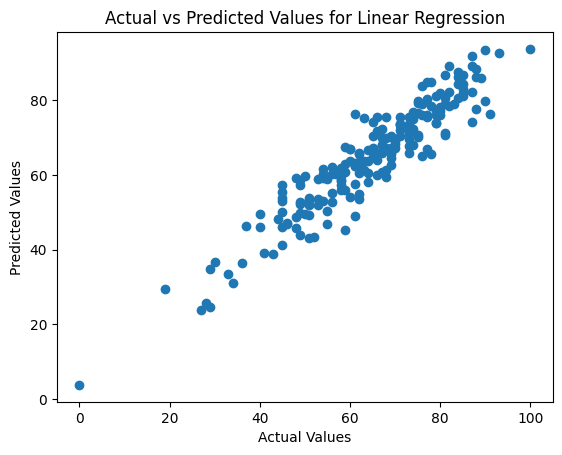

In [88]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values for Linear Regression")


<Axes: xlabel='math_score'>

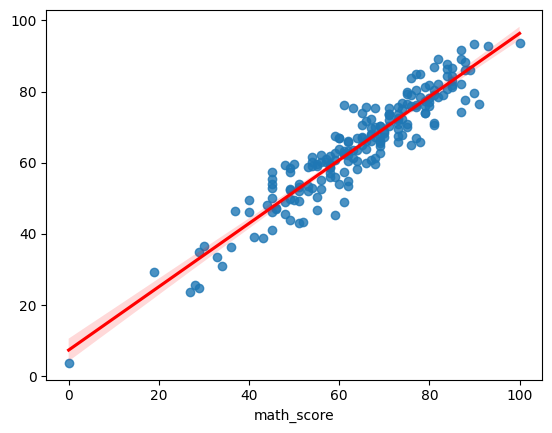

In [89]:
sns.regplot(x=y_test, y=y_test_pred, line_kws={"color": "red"})

In [90]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred, 'Residuals': y_test - y_test_pred})
pred_df.head()

,Actual,Predicted,Residuals
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
